# ♠️ EDA и кластеризация игроков

**Этап 3** проекта *Texas Hold'em ETL & Analytics Pipeline*.

В предыдущих этапах мы загрузили 1000 раздач в SQLite и построили SQL-витрину
`v_player_stats`, где стиль игрока (`player_style`) определяется **правилом**,
написанным вручную (пороги по VPIP и PFR). Здесь проверяем гипотезу:

> Могут ли алгоритмы **без учителя** сами найти те же 4 профиля —
> Nit, TAG, LAG и Loose-Passive (Fish) — по статистике игры?

Проверяем два подхода: **K-Means** (жёсткие метки, сферические кластеры) и
**Gaussian Mixture** (вероятности принадлежности, эллиптические кластеры),
на признаках префлопа **и** постфлопа.

У синтетических данных есть редкое преимущество — **ground truth**: генератор
сохранил настоящий архетип каждого игрока в `data/raw/player_profiles.csv`.
Поэтому качество кластеризации можно измерить честно, а не «на глаз».

**Содержание**
1. Загрузка данных из витрины
2. Разведочный анализ (EDA): корреляции метрик, распределение банков
3. Признаки: префлоп (VPIP, PFR, 3-bet) + постфлоп (AF, WTSD)
4. Две модели: K-Means и Gaussian Mixture — метрики и вероятности
5. PCA: проекции обеих моделей рядом
6. Динамика банкролла (оконные функции SQL)
7. Выводы

## 0. Настройка окружения

Переиспользуем код из `src/analytics.py`: единый стиль графиков, палитру и
функцию установки SQL-витрин. Так ноутбук и скрипты выглядят как одна система.

In [1]:
from __future__ import annotations

import sqlite3
import sys
from contextlib import closing
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.figure import Figure
from matplotlib.lines import Line2D
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Ноутбук запускается из notebooks/ — корень репозитория на уровень выше
PROJECT_ROOT: Final[Path] = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from analytics import (  # noqa: E402  — импорт после настройки sys.path
    ARCHETYPE_TO_STYLE,
    BASELINE_COLOR,
    GRID_COLOR,
    INK_MUTED,
    INK_PRIMARY,
    INK_SECONDARY,
    LOSS_COLOR,
    NEUTRAL_MID,
    STYLE_MARKERS,
    STYLE_ORDER,
    WIN_COLOR,
    apply_chart_style,
    install_views,
)

DB_PATH: Final[Path] = PROJECT_ROOT / "data" / "poker_analytics.db"
SQL_PATH: Final[Path] = PROJECT_ROOT / "sql" / "analytics_queries.sql"
PROFILES_PATH: Final[Path] = PROJECT_ROOT / "data" / "raw" / "player_profiles.csv"
FIGURES_DIR: Final[Path] = PROJECT_ROOT / "reports" / "figures"

# Признаки моделей: префлоп-частоты + постфлоп-поведение (см. раздел 3)
FEATURES_PREFLOP: Final[list[str]] = ["vpip_pct", "pfr_pct", "three_bet_pct"]
FEATURES_POSTFLOP: Final[list[str]] = ["af_share", "wtsd_pct"]
FEATURES_ALL: Final[list[str]] = FEATURES_PREFLOP + FEATURES_POSTFLOP
N_CLUSTERS: Final[int] = 4
K_RANGE: Final[range] = range(2, 9)
RANDOM_STATE: Final[int] = 42
N_INIT: Final[int] = 30            # перезапусков EM / K-Means из разных инициализаций
TOP_N_BANKROLL: Final[int] = 3

# Категориальная палитра (проверена на различимость при дальтонизме).
# Цвет закреплён за СТИЛЕМ, а не за номером кластера — чтобы легенды совпадали.
STYLE_COLORS: Final[dict[str, str]] = {
    "Nit": "#2a78d6", "TAG": "#eb6834", "LAG": "#1baf7a", "Loose-Passive": "#eda100",
}

apply_chart_style()
pd.set_option("display.precision", 2)
pd.set_option("display.width", 140)


def query(sql: str, params: dict[str, object] | None = None) -> pd.DataFrame:
    """Выполняет SQL к poker_analytics.db и возвращает DataFrame."""
    with closing(sqlite3.connect(DB_PATH)) as conn:
        return pd.read_sql_query(sql, conn, params=params)


def save_figure(fig: Figure, name: str) -> None:
    """Сохраняет график в reports/figures (для README), не закрывая его в ноутбуке."""
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES_DIR / name, dpi=200)

## 1. Загрузка данных из витрины

Пересоздаём витрины (скрипт идемпотентен) и забираем профиль каждого игрока.
К витрине присоединяем скрытый архетип из генератора — он понадобится только
для оценки качества, **в обучении не участвует**.

In [2]:
with closing(sqlite3.connect(DB_PATH)) as connection:
    install_views(connection, SQL_PATH)

players = query("SELECT * FROM v_player_stats ORDER BY player_id")
profiles = pd.read_csv(PROFILES_PATH, usecols=["name", "archetype"])
players = players.merge(profiles, left_on="player_name", right_on="name", how="left").drop(columns="name")
players["true_style"] = players["archetype"].map(ARCHETYPE_TO_STYLE)

print(f"Игроков: {len(players)}, раздач на игрока: {players['hands'].min()}–{players['hands'].max()}")
display(players[["player_name", "hands", *FEATURES_PREFLOP, "aggression_factor", "wtsd_pct",
                 "bb_per_100", "player_style", "archetype"]].head(8))

Игроков: 30, раздач на игрока: 171–223


,player_name,hands,vpip_pct,pfr_pct,three_bet_pct,aggression_factor,wtsd_pct,bb_per_100,player_style,archetype
0,BigAce,212,33.0,24.5,5.6,4.00,39.0,38.92,LAG,LAG
1,BigRiver,197,26.4,20.3,11.3,4.80,38.7,93.65,LAG,LAG
2,BigShark,203,35.5,14.3,0.0,0.53,72.3,-150.25,Loose-Passive,Fish
3,ColdAce,214,21.5,17.3,9.5,5.67,46.9,73.49,TAG,TAG
4,ColdDonk,205,31.2,9.3,0.0,0.44,57.1,-84.46,Loose-Passive,Fish
5,ColdManiac,192,29.7,23.4,14.3,7.33,21.2,-50.26,LAG,LAG
6,DarkDonk,216,13.0,9.3,0.0,0.88,19.0,21.53,Nit,Nit
7,DarkFish,196,29.1,12.8,6.0,0.78,56.5,-50.26,Loose-Passive,Fish


## 2. Разведочный анализ (EDA)

### 2.1. Описательные статистики и пропуски
`three_bet_pct` = NULL означает, что у игрока не было ни одной возможности 3-бета.
Такое возможно на малой выборке; для кластеризации заменим NULL на 0 —
«не 3-бетил» — и явно это зафиксируем.

In [3]:
metric_columns = [*FEATURES_PREFLOP, "aggression_factor", "wtsd_pct", "bb_per_100"]
print("Пропуски по метрикам:")
print(players[metric_columns].isna().sum().to_string())
display(players[metric_columns].describe().T[["mean", "std", "min", "50%", "max"]])

Пропуски по метрикам:
vpip_pct             0
pfr_pct              0
three_bet_pct        0
aggression_factor    1
wtsd_pct             0
bb_per_100           0


,mean,std,min,50%,max
vpip_pct,21.25,8.69,5.40,20.55,38.90
pfr_pct,14.00,5.53,2.50,13.20,24.90
three_bet_pct,4.84,4.02,0.00,4.15,14.30
aggression_factor,3.54,2.55,0.44,3.00,10.00
wtsd_pct,46.59,15.37,19.00,46.80,77.40
bb_per_100,-0.35,64.33,-150.25,-0.63,115.27


### 2.2. Корреляции метрик
Если признаки сильно коррелированы, K-Means фактически «видит» меньше измерений,
а PCA сможет сжать их почти без потерь.

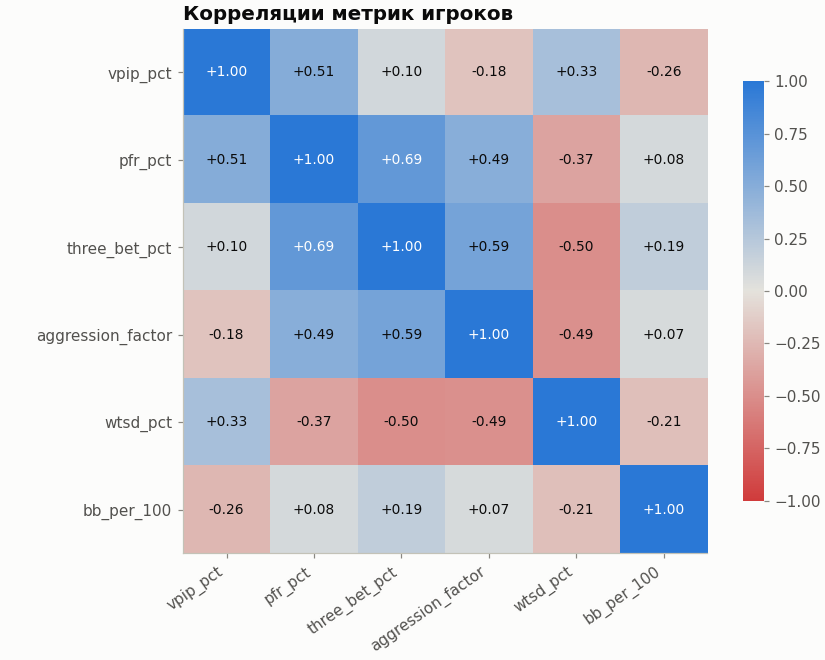

In [4]:
def plot_correlation_matrix(frame: pd.DataFrame, columns: list[str]) -> Figure:
    """Тепловая карта корреляций Пирсона с подписанными значениями."""
    corr = frame[columns].corr().to_numpy()
    cmap = LinearSegmentedColormap.from_list("corr", [LOSS_COLOR, NEUTRAL_MID, WIN_COLOR])

    fig, ax = plt.subplots(figsize=(7.5, 6), layout="constrained")
    image = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
    ax.grid(False)
    ax.set_xticks(range(len(columns)), columns, rotation=35, ha="right")
    ax.set_yticks(range(len(columns)), columns)
    # Подписи значений: тёмный текст на светлых ячейках, белый — на насыщенных
    for (row, col), value in np.ndenumerate(corr):
        ax.text(col, row, f"{value:+.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(value) > 0.6 else INK_PRIMARY)
    colorbar = fig.colorbar(image, ax=ax, shrink=0.8)
    colorbar.outline.set_visible(False)
    ax.set_title("Корреляции метрик игроков")
    return fig


fig_corr = plot_correlation_matrix(players.fillna({"three_bet_pct": 0}), metric_columns)
save_figure(fig_corr, "eda_correlation.png")
plt.show()

### 2.3. Распределение размера банка
Банк в больших блайндах сильно скошен вправо: большинство раздач заканчиваются
префлопом за 1.5–4 BB, а редкие олл-ины нескольких игроков доходят до 300 BB.
Поэтому — логарифмическая ось X.

,count,mean,50%,max
outcome,,,,
Дошла до флопа,390.0,29.34,12.0,301.00
Закончилась префлоп,610.0,3.96,4.0,48.19


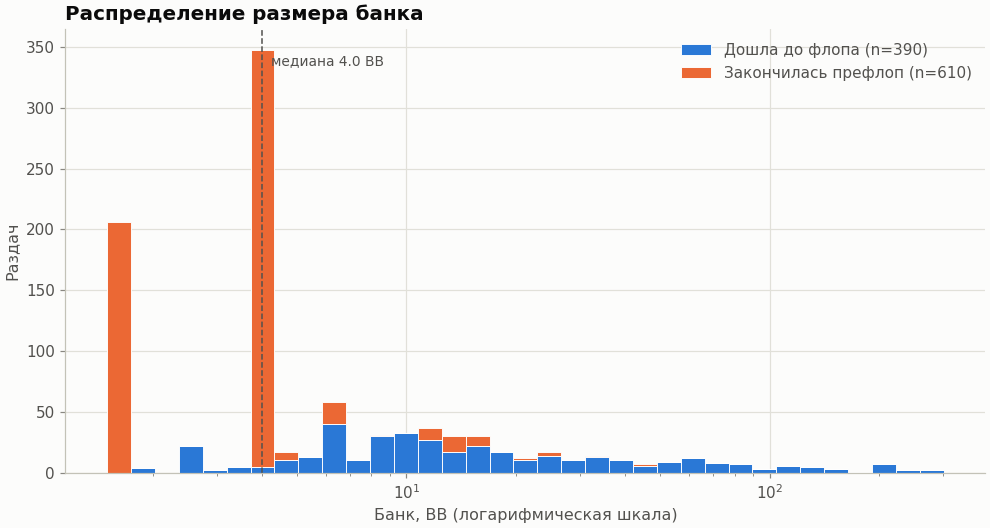

In [5]:
pots = query(
    """
    SELECT CAST(h.pot_size AS REAL) / h.big_blind AS pot_bb,
           CASE WHEN s.street_name = 'preflop' THEN 'Закончилась префлоп'
                ELSE 'Дошла до флопа' END   AS outcome
    FROM hands   AS h
    JOIN streets AS s ON s.street_id = h.final_street_id
    """
)


def plot_pot_distribution(pots_frame: pd.DataFrame) -> Figure:
    """Гистограмма банков в BB на лог-шкале, раздельно по исходу раздачи."""
    bins = np.geomspace(pots_frame["pot_bb"].min(), pots_frame["pot_bb"].max(), 36)
    fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
    groups = list(pots_frame.groupby("outcome", sort=False))
    # stacked=True: столбцы складываются, а не перекрывают друг друга
    ax.hist([group["pot_bb"] for _, group in groups], bins=bins, stacked=True,
            color=[WIN_COLOR, "#eb6834"][: len(groups)], edgecolor="white", linewidth=0.6,
            label=[f"{label} (n={len(group)})" for label, group in groups])
    median = pots_frame["pot_bb"].median()
    ax.axvline(median, color=INK_SECONDARY, linestyle="--", linewidth=1)
    ax.annotate(f"медиана {median:.1f} BB", xy=(median, ax.get_ylim()[1] * 0.92),
                xytext=(6, 0), textcoords="offset points", color=INK_SECONDARY, fontsize=9)
    ax.set_xscale("log")
    ax.set(xlabel="Банк, BB (логарифмическая шкала)", ylabel="Раздач")
    ax.legend(loc="upper right")
    ax.set_title("Распределение размера банка")
    return fig


display(pots.groupby("outcome")["pot_bb"].describe()[["count", "mean", "50%", "max"]])
fig_pots = plot_pot_distribution(pots)
save_figure(fig_pots, "eda_pot_distribution.png")
plt.show()

## 3. Признаки: префлоп + постфлоп

На первой итерации модель видела только префлоп (VPIP, PFR, 3-bet %). Но два
ключевых типажа различаются именно **после флопа**: Fish много коллирует и
доходит до вскрытия, регуляр — ставит и сбрасывает. Добавляем два признака
из витрины: **AF** (agression factor) и **WTSD** (доля вскрытий).

### 3.1. Подготовка матрицы признаков

AF — это отношение (bet + raise) / call, оно не ограничено сверху: в выборке
от 0.44 до 10. Для метода, работающего с евклидовыми расстояниями, такой
тяжёлый хвост означает, что один агрессивный игрок «перетянет» центр кластера.
Сжимаем AF в долю агрессивных действий, которая живёт в [0, 1):

$$\text{af\_share} = \frac{AF}{1 + AF} = \frac{bet + raise}{bet + raise + call}$$

AF = NULL означает, что постфлоп-коллов не было вовсе. Такой игрок в выборке
один, и все его постфлоп-действия агрессивные, поэтому af_share = 1.0.

In [6]:
def add_postflop_features(stats: pd.DataFrame) -> pd.DataFrame:
    """Добавляет af_share — ограниченную версию AF, устойчивую к выбросам."""
    af = stats["aggression_factor"]
    # NaN (не было постфлоп-коллов) → 1.0: все постфлоп-действия были агрессивными
    return stats.assign(af_share=(af / (1.0 + af)).fillna(1.0))


players = add_postflop_features(players)
display(players.groupby("archetype")[FEATURES_ALL].mean().round(2)
        .reindex(["Nit", "TAG", "LAG", "Fish"]))

,vpip_pct,pfr_pct,three_bet_pct,af_share,wtsd_pct
archetype,,,,,
Nit,10.84,7.90,2.10,0.74,43.27
TAG,17.73,14.77,5.82,0.78,42.39
LAG,26.91,21.50,9.06,0.82,38.10
Fish,32.65,11.07,1.48,0.38,67.35


Средние по архетипам показывают, что постфлоп-признаки несут новую информацию:
по VPIP и PFR Nit и Fish — противоположности, но различить TAG и LAG сложно;
зато `af_share` и `wtsd_pct` резко выделяют Fish (мало агрессии, много вскрытий).

### 3.2. Масштабирование и выбор числа кластеров
`StandardScaler` обязателен: признаки измеряются в разных единицах
(проценты 0–100 и доля 0–1), а обе модели опираются на расстояния в этом пространстве.

In [7]:
feature_matrix: npt.NDArray[np.float64] = players[FEATURES_ALL].fillna(0.0).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_matrix)

print("Признаки:", ", ".join(FEATURES_ALL))
print("Средние до масштабирования:", np.round(scaler.mean_, 2))
print("Ст. отклонения:            ", np.round(scaler.scale_, 2))
print("После: mean ≈", np.round(X_scaled.mean(axis=0), 6), " std =", np.round(X_scaled.std(axis=0), 3))

Признаки: vpip_pct, pfr_pct, three_bet_pct, af_share, wtsd_pct
Средние до масштабирования: [21.25 14.    4.84  0.7  46.59]
Ст. отклонения:             [ 8.55  5.43  3.95  0.19 15.11]
После: mean ≈ [ 0.  0.  0. -0. -0.]  std = [1. 1. 1. 1. 1.]


,k,inertia,silhouette
0,2,92.10,0.40
1,3,56.63,0.36
2,4,43.97,0.32
3,5,36.21,0.32
4,6,31.75,0.32
5,7,27.72,0.29
6,8,23.67,0.29


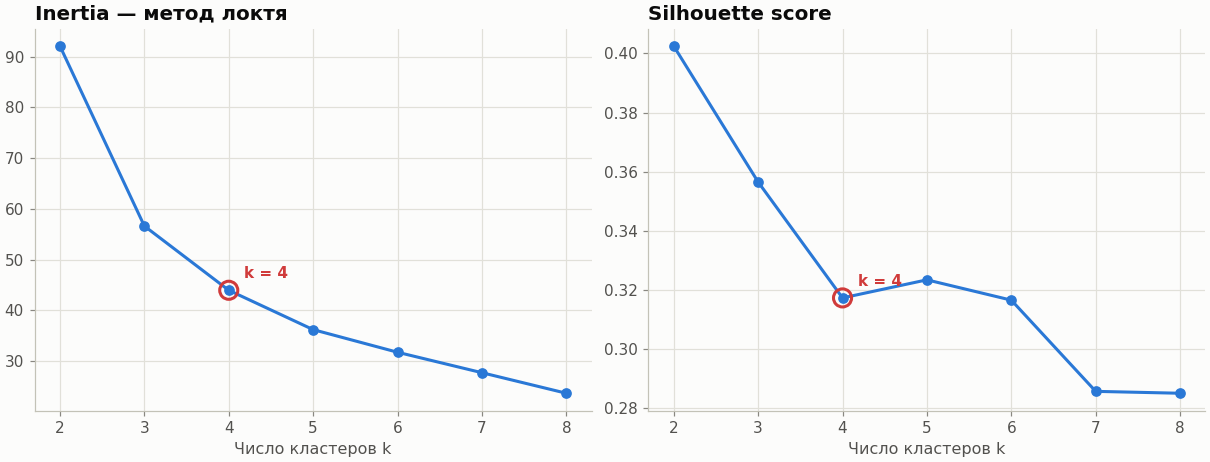

In [8]:
def evaluate_k(X: npt.NDArray[np.float64], k_values: range) -> pd.DataFrame:
    """Inertia и silhouette для каждого k."""
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE).fit(X)
        rows.append({"k": k, "inertia": model.inertia_, "silhouette": silhouette_score(X, model.labels_)})
    return pd.DataFrame(rows)


def plot_k_selection(scores: pd.DataFrame, chosen_k: int) -> Figure:
    """Две панели (разные шкалы — разные графики, без второй оси Y)."""
    fig, (ax_elbow, ax_sil) = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
    panels = [(ax_elbow, "inertia", "Inertia — метод локтя"), (ax_sil, "silhouette", "Silhouette score")]
    for ax, column, title in panels:
        ax.plot(scores["k"], scores[column], color=WIN_COLOR, linewidth=2, marker="o", markersize=6)
        chosen = scores.loc[scores["k"] == chosen_k, column].iloc[0]
        ax.scatter([chosen_k], [chosen], s=140, facecolors="none", edgecolors=LOSS_COLOR, linewidths=2, zorder=3)
        ax.annotate(f"k = {chosen_k}", xy=(chosen_k, chosen), xytext=(10, 8),
                    textcoords="offset points", color=LOSS_COLOR, fontweight="semibold")
        ax.set(xlabel="Число кластеров k", xticks=list(scores["k"]))
        ax.set_title(title)
    return fig


k_scores = evaluate_k(X_scaled, K_RANGE)
display(k_scores)
save_figure(plot_k_selection(k_scores, N_CLUSTERS), "kmeans_k_selection.png")
plt.show()

Локоть по-прежнему приходится на k = 3–4, silhouette для них почти одинаков.
Берём **k = 4**: это обосновано предметной областью (4 классических типажа),
а при k = 3 TAG и LAG склеиваются в одну «регулярную» группу.

## 4. Две модели: K-Means и Gaussian Mixture

| | K-Means | Gaussian Mixture (GMM) |
|---|---|---|
| Что оптимизирует | сумму квадратов расстояний до центров | правдоподобие смеси нормальных распределений (EM-алгоритм) |
| Форма кластера | сфера одинакового радиуса | эллипсоид со своей ковариацией |
| Ответ модели | жёсткая метка «ты TAG» | вероятности: «TAG 0.6 / LAG 0.4» |

### 4.1. Выбор ковариационной матрицы для GMM
`covariance_type` определяет, сколько параметров оценивает модель. При 30 игроках
и 5 признаках `full` (полная матрица на каждый кластер) — уже рискованно.
Сравним варианты по BIC (чем меньше, тем лучше) и посмотрим, что получится.

In [9]:
COVARIANCE_TYPES: Final[tuple[str, ...]] = ("full", "tied", "diag", "spherical")


def fit_gmm(X: npt.NDArray[np.float64], covariance_type: str,
            random_state: int = RANDOM_STATE) -> GaussianMixture:
    """Обучает GMM с заданным типом ковариации.

    n_init=30: EM сходится в локальный оптимум, и на 30 наблюдениях результат
    заметно зависит от инициализации — берём лучший запуск из тридцати.
    """
    return GaussianMixture(
        n_components=N_CLUSTERS, covariance_type=covariance_type,
        n_init=N_INIT, random_state=random_state,
    ).fit(X)


gmm_variants = {covariance: fit_gmm(X_scaled, covariance) for covariance in COVARIANCE_TYPES}
bic_table = pd.DataFrame({
    "covariance_type": list(gmm_variants),
    "параметров": [int(model._n_parameters()) for model in gmm_variants.values()],
    "BIC": [model.bic(X_scaled) for model in gmm_variants.values()],
    # Минимальная по выборке уверенность: если она ≈ 1, модель раздаёт
    # вероятности 0/1 и перестаёт быть «мягкой»
    "min P(кластер)": [model.predict_proba(X_scaled).max(axis=1).min() for model in gmm_variants.values()],
    "размеры кластеров": [np.bincount(model.predict(X_scaled), minlength=N_CLUSTERS).tolist()
                          for model in gmm_variants.values()],
}).sort_values("BIC", ignore_index=True)
display(bic_table.round(2))

,covariance_type,параметров,BIC,min P(кластер),размеры кластеров
0,full,83,329.55,1.00,"[4, 15, 5, 6]"
1,spherical,27,350.70,0.71,"[15, 8, 6, 1]"
2,tied,38,377.25,0.86,"[6, 4, 6, 14]"
3,diag,43,389.23,0.61,"[10, 6, 1, 13]"


BIC формально выбирает `full` — 83 параметра на 30 наблюдений. Но у этой модели
минимальная уверенность по всей выборке ≈ 1.00: каждая точка отнесена к кластеру
с абсолютной вероятностью. Эллипсоиды «облепили» точки, и мягкое отнесение — то,
ради чего берут GMM, — исчезло. Это классический признак переобучения на малой выборке:
BIC на 30 точках слишком слабо штрафует сложность.

Критерий выбора формулируем ДО сравнения с ground truth, чтобы не подглядывать в ответ:
нужна модель, которая (1) сохраняет осмысленные вероятности и (2) допускает разный
разброс признаков. Обоим условиям отвечает **`diag`** — своя дисперсия по каждому
признаку, но без полных ковариационных матриц. Остальные варианты остаются в таблице метрик.

In [10]:
GMM_COVARIANCE: Final[str] = "diag"

kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=N_INIT, random_state=RANDOM_STATE).fit(X_scaled)
gmm = gmm_variants[GMM_COVARIANCE]

players["kmeans_cluster"] = kmeans.labels_
players["gmm_cluster"] = gmm.predict(X_scaled)
gmm_proba = gmm.predict_proba(X_scaled)
players["gmm_confidence"] = gmm_proba.max(axis=1)

# Центры кластеров обеих моделей — обратно в исходные единицы
centers = {"K-Means": kmeans.cluster_centers_, "GMM": gmm.means_}
display(pd.DataFrame(scaler.inverse_transform(gmm.means_), columns=FEATURES_ALL).round(2))

,vpip_pct,pfr_pct,three_bet_pct,af_share,wtsd_pct
0,24.44,19.76,8.05,0.83,39.13
1,32.65,11.07,1.48,0.38,67.35
2,9.80,4.90,0.00,1.00,33.30
3,13.65,10.99,4.01,0.71,44.11


### 4.2. Сопоставление кластеров со стилями и метрики качества

Номера кластеров произвольны, поэтому сначала ищем лучшее взаимно-однозначное
соответствие «кластер → стиль» венгерским алгоритмом, и только потом считаем accuracy.
Метрики ARI и NMI от нумерации не зависят и считаются напрямую.

In [11]:
def match_clusters_to_labels(clusters: pd.Series, labels: pd.Series) -> dict[int, str]:
    """Оптимальное соответствие кластер → метка (максимум совпадений)."""
    contingency = pd.crosstab(clusters, labels).reindex(columns=list(STYLE_ORDER), fill_value=0)
    row_idx, col_idx = linear_sum_assignment(-contingency.to_numpy())   # минус — ищем максимум
    return {int(contingency.index[r]): str(contingency.columns[c]) for r, c in zip(row_idx, col_idx)}


def score_clustering(
    X: npt.NDArray[np.float64], clusters: pd.Series, reference: pd.Series
) -> dict[str, float]:
    """Silhouette (по геометрии) + accuracy, ARI и NMI (по совпадению с эталоном)."""
    predicted = clusters.map(match_clusters_to_labels(clusters, reference))
    return {
        "silhouette": silhouette_score(X, clusters),
        "accuracy": float((predicted.to_numpy() == reference.to_numpy()).mean()),
        "ARI": adjusted_rand_score(reference, clusters),
        "NMI": normalized_mutual_info_score(reference, clusters),
    }


players["kmeans_style"] = players["kmeans_cluster"].map(
    match_clusters_to_labels(players["kmeans_cluster"], players["true_style"]))
players["gmm_style"] = players["gmm_cluster"].map(
    match_clusters_to_labels(players["gmm_cluster"], players["true_style"]))

comparison = pd.DataFrame({
    "K-Means": score_clustering(X_scaled, players["kmeans_cluster"], players["true_style"]),
    f"GMM ({GMM_COVARIANCE})": score_clustering(X_scaled, players["gmm_cluster"], players["true_style"]),
    "GMM (full)": score_clustering(X_scaled, pd.Series(gmm_variants["full"].predict(X_scaled)),
                                   players["true_style"]),
    "SQL-правило": {
        "silhouette": np.nan,
        "accuracy": float((players["player_style"] == players["true_style"]).mean()),
        "ARI": adjusted_rand_score(players["true_style"], players["player_style"]),
        "NMI": normalized_mutual_info_score(players["true_style"], players["player_style"]),
    },
}).T
display(comparison.round(3))

print("\nK-Means (строки) × GMM (столбцы) — где модели расходятся:")
display(pd.crosstab(players["kmeans_style"], players["gmm_style"])
        .reindex(index=list(STYLE_ORDER), columns=list(STYLE_ORDER), fill_value=0))


K-Means (строки) × GMM (столбцы) — где модели расходятся:


,silhouette,accuracy,ARI,NMI
K-Means,0.32,0.87,0.63,0.73
GMM (diag),0.29,0.70,0.49,0.68
GMM (full),0.30,0.60,0.47,0.66
SQL-правило,NaN,0.87,0.66,0.78


gmm_style,Nit,TAG,LAG,Loose-Passive
kmeans_style,,,,
Nit,1,6,0,0
TAG,0,7,5,0
LAG,0,0,5,0
Loose-Passive,0,0,0,6


### 4.3. Что дали постфлоп-признаки?
Честная проверка: обучаем обе модели на старом (только префлоп) и новом наборе
признаков и сравниваем качество восстановления архетипов.

In [12]:
def compare_feature_sets(
    stats: pd.DataFrame, feature_sets: dict[str, list[str]], reference: pd.Series
) -> pd.DataFrame:
    """Таблица «набор признаков × модель» с метриками качества кластеризации."""
    rows = []
    for set_name, features in feature_sets.items():
        X = StandardScaler().fit_transform(stats[features].fillna(0.0).to_numpy())
        models = {
            "K-Means": KMeans(n_clusters=N_CLUSTERS, n_init=N_INIT, random_state=RANDOM_STATE).fit_predict(X),
            f"GMM ({GMM_COVARIANCE})": fit_gmm(X, GMM_COVARIANCE).predict(X),
        }
        for model_name, labels in models.items():
            rows.append({"признаки": set_name, "модель": model_name,
                         **score_clustering(X, pd.Series(labels), reference)})
    return pd.DataFrame(rows)


ablation = compare_feature_sets(
    players,
    {"префлоп (3)": FEATURES_PREFLOP, "префлоп + постфлоп (5)": FEATURES_ALL},
    players["true_style"],
)
display(ablation.round(3))

,признаки,модель,silhouette,accuracy,ARI,NMI
0,префлоп (3),K-Means,0.41,0.87,0.62,0.69
1,префлоп (3),GMM (diag),0.38,0.83,0.56,0.69
2,префлоп + постфлоп (5),K-Means,0.32,0.87,0.63,0.73
3,префлоп + постфлоп (5),GMM (diag),0.29,0.70,0.49,0.68


### 4.4. Устойчивость: а не повезло ли нам с random_state?
Одна пара чисел ничего не доказывает. Переобучаем обе модели на десяти разных
инициализациях и смотрим разброс качества.

In [13]:
SEEDS: Final[range] = range(10)


def stability_check(X: npt.NDArray[np.float64], reference: pd.Series, seeds: range) -> pd.DataFrame:
    """Accuracy и ARI при разных random_state — мера воспроизводимости результата."""
    rows = []
    for seed in seeds:
        labels = {
            "K-Means": KMeans(n_clusters=N_CLUSTERS, n_init=N_INIT, random_state=seed).fit_predict(X),
            f"GMM ({GMM_COVARIANCE})": fit_gmm(X, GMM_COVARIANCE, random_state=seed).predict(X),
        }
        for model_name, clusters in labels.items():
            scores = score_clustering(X, pd.Series(clusters), reference)
            rows.append({"модель": model_name, "seed": seed,
                         "accuracy": scores["accuracy"], "ARI": scores["ARI"]})
    runs = pd.DataFrame(rows)
    return runs.groupby("модель").agg(
        accuracy_mean=("accuracy", "mean"), accuracy_min=("accuracy", "min"),
        accuracy_max=("accuracy", "max"), ARI_mean=("ARI", "mean"), ARI_std=("ARI", "std"),
    ).reset_index()


display(stability_check(X_scaled, players["true_style"], SEEDS).round(3))

,модель,accuracy_mean,accuracy_min,accuracy_max,ARI_mean,ARI_std
0,GMM (diag),0.69,0.63,0.77,0.49,0.03
1,K-Means,0.87,0.87,0.87,0.63,0.00


### 4.5. Вероятности GMM: кто «между стилями»
Главное отличие GMM — мягкое отнесение. Посмотрим на игроков, у которых
максимальная вероятность ниже 0.9: модель сама сообщает, что случай пограничный.

Игроков с уверенностью ниже 90%: 4 из 30


,player_name,Nit,TAG,LAG,Loose-Passive,true_style,confidence
10,IronManiac,0.0,0.61,3.86e-01,0.0,TAG,0.61
13,LuckyBluff,0.0,0.67,3.26e-01,0.0,TAG,0.67
9,DarkRock,0.0,0.76,2.40e-01,0.0,TAG,0.76
15,RoyalAce,0.0,0.13,8.74e-01,0.0,TAG,0.87
12,IronShark,0.0,0.96,4.30e-02,0.0,TAG,0.96
11,IronRiver,0.0,0.99,5.00e-03,0.0,TAG,0.99


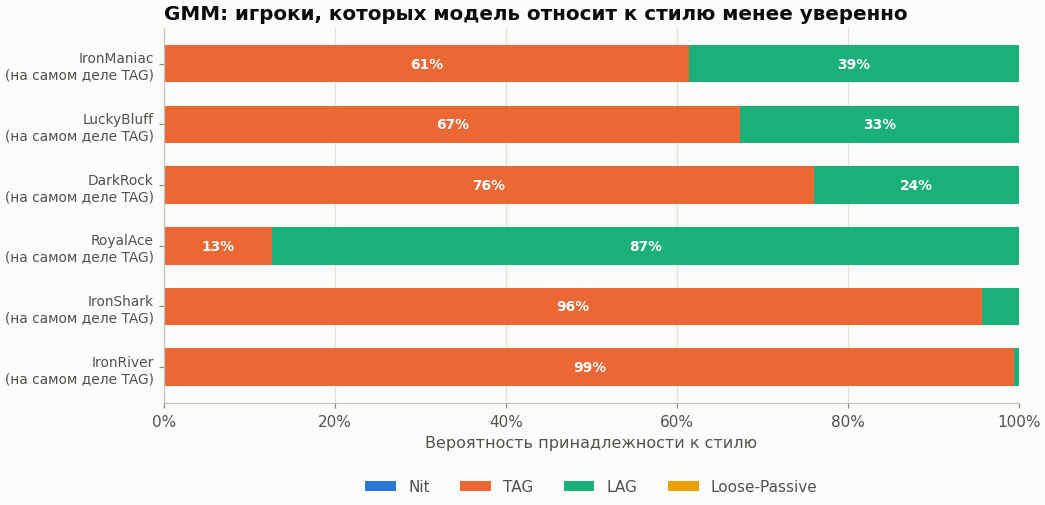

In [14]:
CONFIDENCE_THRESHOLD: Final[float] = 0.90

gmm_cluster_names = match_clusters_to_labels(players["gmm_cluster"], players["true_style"])
probabilities = pd.DataFrame(gmm_proba, columns=[gmm_cluster_names[i] for i in range(N_CLUSTERS)])
probabilities = probabilities[list(STYLE_ORDER)]      # фиксированный порядок стилей
probabilities.insert(0, "player_name", players["player_name"])
probabilities["true_style"] = players["true_style"]
probabilities["confidence"] = players["gmm_confidence"]

uncertain = probabilities.sort_values("confidence").head(6)
print(f"Игроков с уверенностью ниже {CONFIDENCE_THRESHOLD:.0%}: "
      f"{int((probabilities['confidence'] < CONFIDENCE_THRESHOLD).sum())} из {len(players)}")
display(uncertain.round(3))


def plot_gmm_confidence(frame: pd.DataFrame) -> Figure:
    """Горизонтальные стековые бары: как GMM распределяет вероятность между стилями."""
    fig, ax = plt.subplots(figsize=(9.5, 4.6), layout="constrained")
    y = np.arange(len(frame))
    left = np.zeros(len(frame))
    for style in STYLE_ORDER:
        widths = frame[style].to_numpy()
        ax.barh(y, widths, left=left, height=0.62, color=STYLE_COLORS[style], label=style)
        for yi, (width, start) in enumerate(zip(widths, left)):
            if width > 0.12:      # подписываем только сегменты, где текст помещается
                ax.text(start + width / 2, yi, f"{width:.0%}", ha="center", va="center",
                        fontsize=9, color="white", fontweight="semibold")
        left += widths
    ax.set_yticks(y, [f"{row.player_name}\n(на самом деле {row.true_style})"
                      for row in frame.itertuples(index=False)], fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, 1)
    ax.set_xticks(np.linspace(0, 1, 6), [f"{v:.0%}" for v in np.linspace(0, 1, 6)])
    ax.set_xlabel("Вероятность принадлежности к стилю")
    ax.legend(ncols=4, loc="lower center", bbox_to_anchor=(0.5, -0.28))
    ax.set_title("GMM: игроки, которых модель относит к стилю менее уверенно")
    return fig


fig_confidence = plot_gmm_confidence(uncertain)
save_figure(fig_confidence, "gmm_confidence.png")
plt.show()

## 5. PCA: две модели рядом

Пять признаков → две главные компоненты. На обеих панелях:
**цвет** — стиль, предсказанный моделью, **форма** — настоящий архетип из генератора,
**красная обводка** — ошибка. На панели GMM прозрачность точки отражает уверенность:
бледная точка = модель сомневается.

Объяснённая дисперсия: PC1 = 51.1%, PC2 = 32.8%, вместе = 83.9%


,PC1,PC2
vpip_pct,-0.07,0.75
pfr_pct,0.45,0.49
three_bet_pct,0.53,0.20
af_share,0.51,-0.31
wtsd_pct,-0.49,0.24


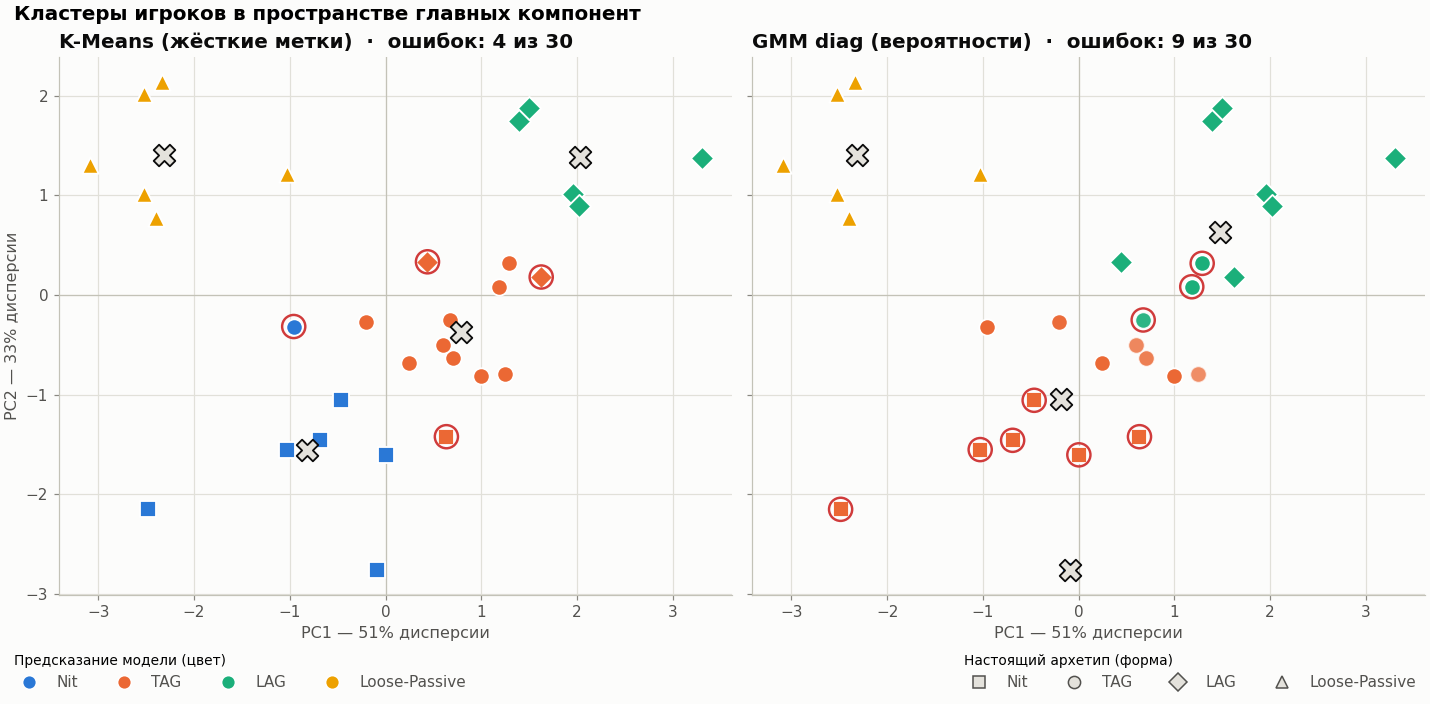

In [15]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
players[["pc1", "pc2"]] = coords
explained = pca.explained_variance_ratio_

print(f"Объяснённая дисперсия: PC1 = {explained[0]:.1%}, PC2 = {explained[1]:.1%}, "
      f"вместе = {explained.sum():.1%}")
display(pd.DataFrame(pca.components_.T, index=FEATURES_ALL, columns=["PC1", "PC2"]).round(3))


def _draw_cluster_panel(
    ax: Axes, frame: pd.DataFrame, style_column: str, centers_2d: npt.NDArray[np.float64],
    title: str, confidence: pd.Series | None = None,
) -> None:
    """Одна панель: точки игроков, центры кластеров и обводка ошибок."""
    alphas = (0.35 + 0.65 * confidence) if confidence is not None else pd.Series(1.0, index=frame.index)
    for row, alpha in zip(frame.itertuples(index=False), alphas):
        ax.scatter(row.pc1, row.pc2, s=115, color=STYLE_COLORS[getattr(row, style_column)],
                   marker=STYLE_MARKERS[row.true_style], edgecolors="white", linewidths=1.2,
                   alpha=float(alpha), zorder=3)

    mistakes = frame[frame[style_column] != frame["true_style"]]
    ax.scatter(mistakes["pc1"], mistakes["pc2"], s=230, facecolors="none",
               edgecolors=LOSS_COLOR, linewidths=1.6, zorder=4)

    ax.scatter(centers_2d[:, 0], centers_2d[:, 1], marker="X", s=200, color=NEUTRAL_MID,
               edgecolors=INK_PRIMARY, linewidths=1.2, zorder=5)
    ax.axhline(0, color=BASELINE_COLOR, linewidth=0.8, zorder=1)
    ax.axvline(0, color=BASELINE_COLOR, linewidth=0.8, zorder=1)
    ax.set_title(f"{title}  ·  ошибок: {len(mistakes)} из {len(frame)}")


def plot_models_side_by_side(frame: pd.DataFrame, pca_model: PCA) -> Figure:
    """PCA-проекции K-Means и GMM бок о бок: общие оси, общая палитра, общие маркеры."""
    fig, (ax_km, ax_gmm) = plt.subplots(1, 2, figsize=(13, 6.4), layout="constrained",
                                        sharex=True, sharey=True)
    _draw_cluster_panel(ax_km, frame, "kmeans_style",
                        pca_model.transform(centers["K-Means"]), "K-Means (жёсткие метки)")
    _draw_cluster_panel(ax_gmm, frame, "gmm_style",
                        pca_model.transform(centers["GMM"]), f"GMM {GMM_COVARIANCE} (вероятности)",
                        confidence=frame["gmm_confidence"])

    for ax in (ax_km, ax_gmm):
        ax.set_xlabel(f"PC1 — {explained[0]:.0%} дисперсии")
    ax_km.set_ylabel(f"PC2 — {explained[1]:.0%} дисперсии")

    color_handles = [Line2D([], [], marker="o", linestyle="none", markersize=9,
                            markerfacecolor=STYLE_COLORS[s], markeredgecolor="white", label=s)
                     for s in STYLE_ORDER]
    shape_handles = [Line2D([], [], marker=STYLE_MARKERS[s], linestyle="none", markersize=8,
                            markerfacecolor=NEUTRAL_MID, markeredgecolor=INK_SECONDARY, label=s)
                     for s in STYLE_ORDER]
    fig.legend(handles=color_handles, loc="outside lower left", ncols=4,
               title="Предсказание модели (цвет)", title_fontsize=9, alignment="left")
    fig.legend(handles=shape_handles, loc="outside lower right", ncols=4,
               title="Настоящий архетип (форма)", title_fontsize=9, alignment="left")
    fig.suptitle("Кластеры игроков в пространстве главных компонент", fontsize=13,
                 fontweight="semibold", x=0.01, ha="left")
    return fig


fig_models = plot_models_side_by_side(players, pca)
save_figure(fig_models, "clusters_kmeans_vs_gmm.png")
plt.show()

### 5.1. На ком ошибаются модели
Сводим ошибки обеих моделей в одну таблицу: видно, спорят ли они об одних и тех же игроках.

In [16]:
disagreements = players.loc[
    (players["kmeans_style"] != players["true_style"]) | (players["gmm_style"] != players["true_style"]),
    ["player_name", *FEATURES_ALL, "true_style", "kmeans_style", "gmm_style", "gmm_confidence"],
]
print(f"Игроков, где хотя бы одна модель ошиблась: {len(disagreements)} из {len(players)}")
display(disagreements.sort_values("vpip_pct").round(2))

Игроков, где хотя бы одна модель ошиблась: 12 из 30


,player_name,vpip_pct,pfr_pct,three_bet_pct,af_share,wtsd_pct,true_style,kmeans_style,gmm_style,gmm_confidence
22,SneakyRiver,5.4,2.5,0.0,0.57,66.7,Nit,Nit,TAG,1.00
29,WildDonk,9.8,7.7,2.7,0.75,60.0,Nit,Nit,TAG,1.00
19,SilentRock,11.6,9.6,3.0,0.71,31.3,Nit,Nit,TAG,1.00
6,DarkDonk,13.0,9.3,0.0,0.47,19.0,Nit,Nit,TAG,1.00
14,LuckyRock,13.0,11.4,2.9,0.78,54.5,Nit,Nit,TAG,1.00
28,TiltedShark,13.3,9.9,6.1,0.88,38.1,Nit,TAG,TAG,1.00
20,SilentShark,16.7,12.6,2.7,0.60,56.5,TAG,Nit,TAG,1.00
15,RoyalAce,19.6,16.7,4.2,0.91,47.6,TAG,TAG,LAG,0.87
3,ColdAce,21.5,17.3,9.5,0.85,46.9,TAG,TAG,LAG,1.00
21,SneakyManiac,21.8,18.8,5.0,0.82,33.3,TAG,TAG,LAG,1.00


## 6. Динамика банкролла

Считаем кумулятивный профит **прямо в SQL** оконной функцией
`SUM(...) OVER (PARTITION BY player ORDER BY time)`. Игроков выбираем в CTE:
топ-3 по итоговому профиту и топ-3 по убытку (`ROW_NUMBER()` в обе стороны).
Профит переводим в большие блайнды, чтобы результат не зависел от ставок стола.

In [17]:
BANKROLL_SQL: Final[str] = """
WITH totals AS (
    SELECT player_id, SUM(net_result) AS total_net
    FROM hand_players
    GROUP BY player_id
),
ranked AS (
    SELECT player_id,
           ROW_NUMBER() OVER (ORDER BY total_net DESC) AS rank_best,
           ROW_NUMBER() OVER (ORDER BY total_net ASC)  AS rank_worst
    FROM totals
),
selected AS (
    SELECT player_id,
           CASE WHEN rank_best <= :top_n THEN 'winner' ELSE 'loser' END AS player_group
    FROM ranked
    WHERE rank_best <= :top_n OR rank_worst <= :top_n
)
SELECT
    p.player_name,
    s.player_group,
    h.hand_id,
    h.played_at,
    ROW_NUMBER() OVER player_timeline                                  AS hand_no,
    SUM(CAST(hp.net_result AS REAL) / h.big_blind) OVER (
        player_timeline ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    )                                                                  AS cumulative_bb
FROM selected     AS s
JOIN hand_players AS hp ON hp.player_id = s.player_id
JOIN hands        AS h  ON h.hand_id    = hp.hand_id
JOIN players      AS p  ON p.player_id  = s.player_id
WINDOW player_timeline AS (PARTITION BY hp.player_id ORDER BY h.played_at, h.hand_id)
ORDER BY p.player_name, hand_no
"""

bankroll = query(BANKROLL_SQL, params={"top_n": TOP_N_BANKROLL})
bankroll["played_at"] = pd.to_datetime(bankroll["played_at"])

final_results = (bankroll.groupby(["player_name", "player_group"], as_index=False)
                 .agg(hands=("hand_no", "max"), final_bb=("cumulative_bb", "last"),
                      peak_bb=("cumulative_bb", "max"), trough_bb=("cumulative_bb", "min"))
                 .sort_values("final_bb", ascending=False, ignore_index=True))
final_results = final_results.merge(players[["player_name", "player_style", "true_style"]], on="player_name")
display(final_results)

,player_name,player_group,hands,final_bb,peak_bb,trough_bb,player_style,true_style
0,SneakyRiver,winner,203,234.00,236.5,-5.50,Nit,Nit
1,TiltedBluff,winner,193,199.00,211.0,-19.00,LAG,LAG
2,BigRiver,winner,197,184.50,189.5,-7.50,LAG,LAG
3,ColdDonk,loser,205,-173.15,7.0,-175.65,Loose-Passive,Loose-Passive
4,RoyalBluff,loser,215,-177.00,37.0,-216.50,Loose-Passive,Loose-Passive
5,BigShark,loser,203,-305.00,21.5,-307.50,Loose-Passive,Loose-Passive


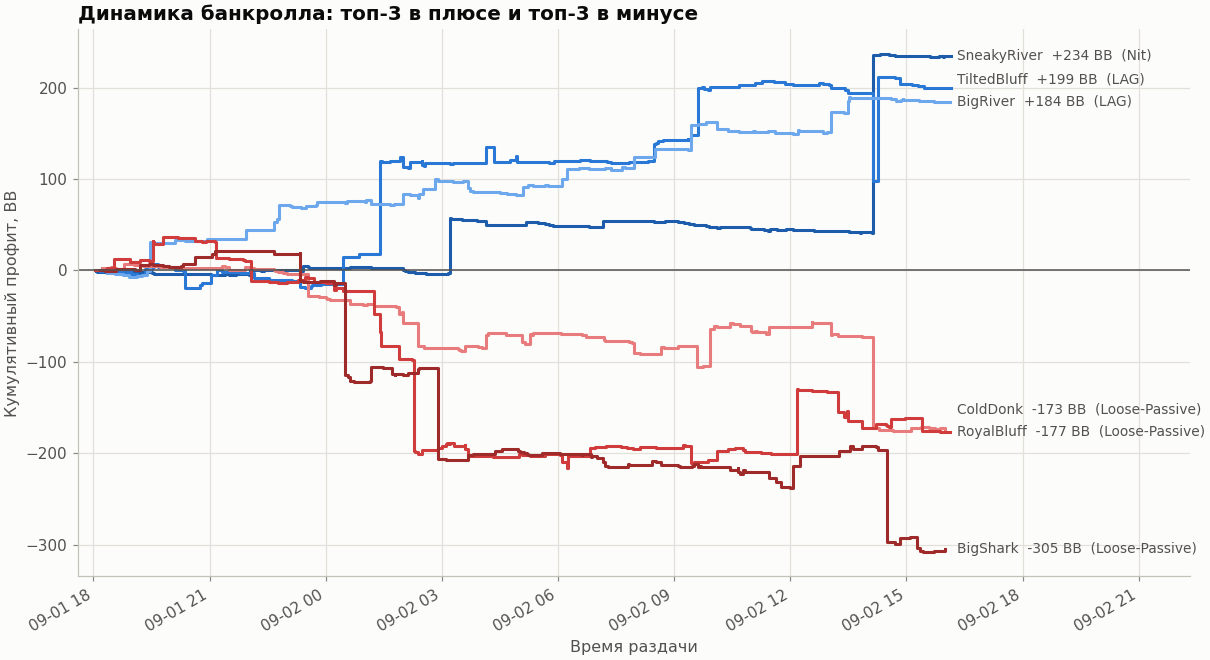

In [18]:
# Оттенки внутри группы: победители — синие, проигравшие — красные.
# Идентичность игрока дублируется подписью в конце линии (не только цветом).
GROUP_SHADES: Final[dict[str, list[str]]] = {
    "winner": ["#1c5cab", "#2a78d6", "#6da7ec"],
    "loser": ["#e87b7b", "#d03b3b", "#9e2a2a"],   # порядок: от меньшего убытка к большему
}


def spread_labels(values: npt.NDArray[np.float64], min_gap: float) -> npt.NDArray[np.float64]:
    """Раздвигает Y-координаты подписей снизу вверх, чтобы между ними было не меньше min_gap."""
    placed = values.astype(float).copy()
    order = np.argsort(values)
    for previous, current in zip(order[:-1], order[1:]):
        placed[current] = max(placed[current], placed[previous] + min_gap)
    return placed


def plot_bankroll(frame: pd.DataFrame, results: pd.DataFrame) -> Figure:
    """Кумулятивный профит в BB во времени для лучших и худших игроков."""
    fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
    shade_iter = {group: iter(shades) for group, shades in GROUP_SHADES.items()}

    y_span = frame["cumulative_bb"].max() - frame["cumulative_bb"].min()
    label_y = spread_labels(results["final_bb"].to_numpy(), min_gap=0.045 * y_span)
    label_x = frame["played_at"].max() + pd.Timedelta(minutes=10)

    for row, y_text in zip(results.itertuples(index=False), label_y):
        series = frame[frame["player_name"] == row.player_name]
        color = next(shade_iter[row.player_group])
        ax.plot(series["played_at"], series["cumulative_bb"], color=color, linewidth=2,
                drawstyle="steps-post")
        ax.text(label_x, y_text, f"{row.player_name}  {row.final_bb:+.0f} BB  ({row.player_style})",
                va="center", fontsize=9, color=INK_SECONDARY)

    ax.axhline(0, color=INK_SECONDARY, linewidth=1)
    ax.set(ylabel="Кумулятивный профит, BB", xlabel="Время раздачи")
    ax.margins(x=0.02)
    ax.set_xlim(right=frame["played_at"].max() + (frame["played_at"].max() - frame["played_at"].min()) * 0.28)
    fig.autofmt_xdate()
    ax.set_title(f"Динамика банкролла: топ-{TOP_N_BANKROLL} в плюсе и топ-{TOP_N_BANKROLL} в минусе")
    return fig


fig_bankroll = plot_bankroll(bankroll, final_results)
save_figure(fig_bankroll, "bankroll_dynamics.png")
plt.show()

## 7. Выводы

**EDA**
* 61% раздач заканчиваются префлоп (медиана банка 4 BB). Раздачи, дошедшие до флопа,
  дают медианный банк 12 BB и хвост до 300 BB — распределение логнормальное.
* PFR и 3-bet % сильно связаны (r = 0.69), AF и WTSD — обратно (r = −0.49):
  агрессивные игроки забирают банки ставками и реже доходят до вскрытия.

**Что дали постфлоп-признаки**
* Они разделяют именно тот типаж, который префлоп-частоты видят хуже всего:
  у Fish af_share = 0.38 и WTSD = 67% против 0.74–0.82 и 38–43% у остальных.
* Но accuracy K-Means не изменилась (0.87), выросла только NMI: 0.69 → 0.73.
  Причина в том, что TAG и LAG различаются по-прежнему только префлопом,
  а именно на их границе модель и ошибается. Для GMM добавление признаков
  оказалось вредным: 0.83 → 0.70 (см. ниже, почему).

**Какая модель точнее восстановила стили: K-Means**

| Модель | Accuracy | ARI | NMI | Разброс по 10 seed |
|---|---|---|---|---|
| K-Means | **0.87** (26/30) | **0.63** | **0.73** | 0.87 → 0.87 (ноль) |
| GMM (diag) | 0.70 | 0.49 | 0.68 | 0.63 → 0.77 |
| GMM (full, выбран по BIC) | 0.60 | 0.47 | 0.66 | — |
| SQL-правило (ручные пороги) | 0.87 | 0.66 | 0.78 | — |

Три причины проигрыша GMM именно здесь:
1. **Параметров больше, чем данных.** K-Means оценивает 4 × 5 = 20 чисел,
   GMM (diag) — 43, GMM (full) — 83. Наблюдений всего 30.
2. **Вырожденный кластер.** GMM выделил компоненту из одного игрока —
   TiltedDonk, единственный без постфлоп-коллов (af_share = 1.0). Кластер
   «схлопнулся» на выбросе, а настоящие Nit слились с TAG.
3. **BIC не спас.** Формально он выбрал `full`, но у этой модели минимальная
   вероятность по выборке равна 1.00: вероятности выродились в жёсткие метки.
   На 30 точках штраф за сложность слишком слабый.

**Почему вероятности GMM концептуально ближе к покеру**

Стиль игрока — не ящик, а континуум. Один и тот же человек с UTG играет как Nit,
а с баттона — как LAG; за сессией стиль дрейфует. Жёсткая метка K-Means это
стирает, а GMM отвечает «IronManiac: TAG 61% / LAG 39%» — и такая запись
честнее отражает реальность. Практически это даёт три вещи, которых у K-Means нет:
* **порог доверия** — пограничных игроков (у нас 4 из 30 с уверенностью < 90%)
  можно не размечать автоматически, а отправлять на ручной разбор;
* **разную форму кластеров** — разброс VPIP по пулу почти вдвое шире разброса
  3-bet, а K-Means считает все кластеры сферами одинакового радиуса;
* **порождающую модель** — из GMM можно сэмплировать «типичного TAG»
  и считать правдоподобие новых игроков, не переобучая кластеризацию.

Цена этой гибкости — данные. На 30 игроках GMM переобучается, на десятках тысяч
раздач и сотнях игроков ситуация должна развернуться в его пользу.

**Банкролл**
* Все три худших игрока — Loose-Passive (от −173 до −305 BB), лучшие — Nit и два LAG.
* Кривые растут ступенями: итог часто решают 1–2 крупных банка (у SneakyRiver
  +195 BB за одну раздачу). 200 раздач на игрока — это ещё не навык, а во многом дисперсия.

**Что делать дальше**
* Прогнать `--hands 200000 --players 80`: проверить гипотезу, что на большей выборке
  GMM обгонит K-Means, а границы TAG/LAG станут чётче.
* Для GMM — регуляризация ковариаций (`reg_covar`) и выбор `covariance_type`
  по кросс-валидации правдоподобия, а не по BIC на 30 точках.
* Добавить признаки, устойчивые на малой выборке: fold to c-bet, steal %,
  агрессия по улицам отдельно.